<a href="https://colab.research.google.com/github/dagudelo30/Series-de-tiempo---Javeriana-Cali/blob/main/intro-moving_average/intro_moving_average.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Pronósticos basados en series de tiempo

## Diego Fernando Agudelo
## Universidad Javeriana-Cali
## diegoagudelo30@gmail.com


## **1. Carga de paquetes**

In [1]:
import numpy as np
import pandas as pd  # Operaciones con dataframes
from matplotlib import pyplot as plt  # Gráficos
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose  # Descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


Este documento presenta una breve introducción a la construcción de objetos de series de tiempo y el cálculo de pronósticos con modelos de suavización.

Para este ejercicio emplearemos la información disponible en el archivo datosEmpleo.xlsx. En ese archivo econtrarán la tasa de desempleo mensual de las 13 principales ciudades en Colombia (TD_13ciudades). El archivo también contiene series mensuales para las 13 principales ciudades de Colombia el número de ocupados en miles de personas (Ocupados), los desocupados (Desocupados) y los inactivos (Inactivos).

## **2. Carga de datos**

Nuestra primera tarea será leer el archivo de Excel. Para eso podemos emplear el paquete Pandas. Carguemos los datos en un objeto que denominaremos data.

In [2]:
# Lectura de la base de datos
# En Colab se puede leer desde GitHub. Si el archivo datosEmpleo.xlsx está cargado localmente,
# también puede usarse la ruta local.
url = "https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx"

try:
    data = pd.read_excel("datosEmpleo.xlsx", index_col="mes", parse_dates=True)
except Exception:
    data = pd.read_excel(url, index_col="mes", parse_dates=True)

data = data.sort_index()
data.head()


,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


En este caso los datos fueron leídos como un data frame y adicionalmente la columna "mes" fue seleccionada como indice, con el dataframe de esta forma sera más facil trabajar las series de tiempo.

A continuación se gráfica la tasa de desempleo.



(222, 4)


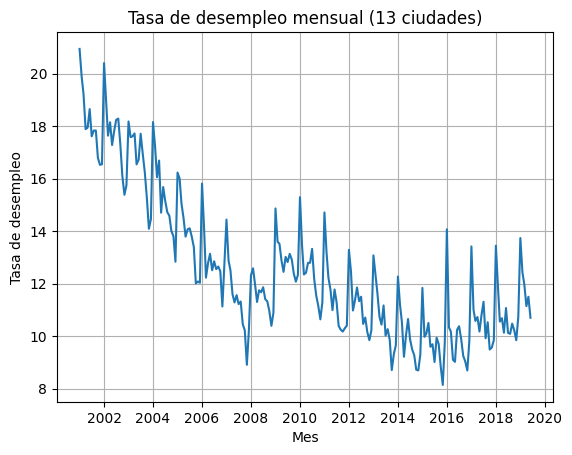

In [3]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
plt.title("Tasa de desempleo mensual (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Tasa de desempleo")
plt.plot(data[["TD_13ciudades"]])
plt.grid()
plt.show()

## **3. Encontrando los componentes de una serie de tiempo**

En algunas ocasiones puede ser útil empezar nuestro análisis descomponiendo la serie de tiempo en sus componentes: **tendencia**, **estacionalidad** y **componente puramente aleatorio**. Una forma de hacer esto es empleando la función seasonal_decompose.

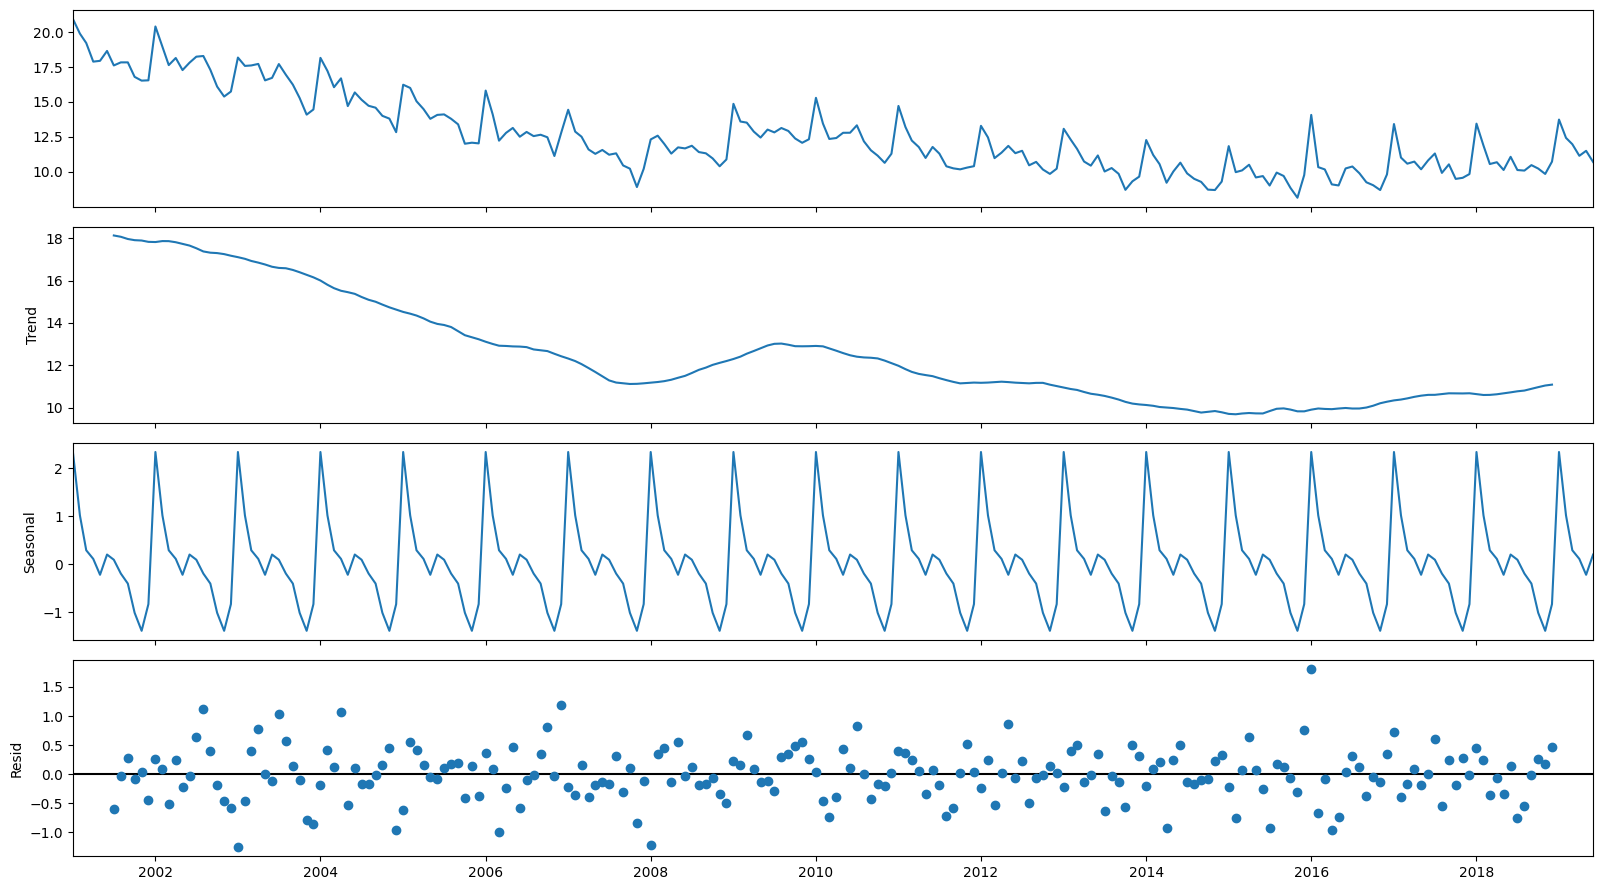

In [4]:
td_componentes = seasonal_decompose(data[["TD_13ciudades"]],model="additive")
fig = td_componentes.plot()
fig.set_size_inches((16, 9))
fig.tight_layout()
plt.show()

Asi se extrae cada elemento de la descomposición de la serie.

In [5]:
td_componentes.seasonal
#td_componentes.trend
#td_componentes.resid

,seasonal
mes,
2001-01-01,2.337888
2001-02-01,1.017106
2001-03-01,0.290193
2001-04-01,0.110715
2001-05-01,-0.220208
...,...
2019-02-01,1.017106
2019-03-01,0.290193
2019-04-01,0.110715


Podemos observar el componente estacional marcado en la serie, una tendencia no lineal de los datos y la parte aleatoria.

Es importante mencionar que esta descomposición se emplea solo como referencia para iniciar el análisis.

Antes de entrar a trabajar con los métodos de suavizamiento, vale la pena anotar que una forma sencilla y rápida para quitar el componente estacional (desestacionalizar) es restarle a la serie el componente estacional encontrado en la descomposición. Es decir,

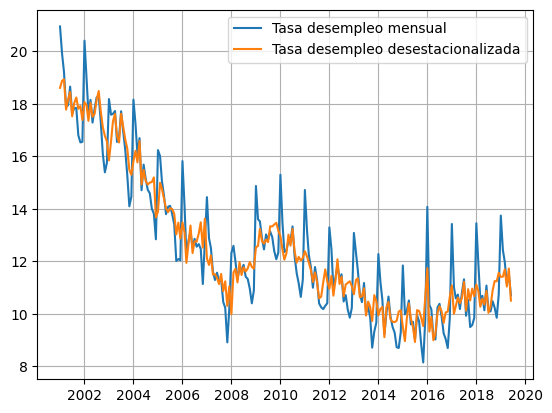

In [6]:
td_desestacionalizada = data["TD_13ciudades"]-td_componentes.seasonal

plt.plot(data[["TD_13ciudades"]],label="Tasa desempleo mensual")
plt.plot(td_desestacionalizada,label="Tasa desempleo desestacionalizada")
plt.legend()
plt.grid()
plt.show()


## **4. Protocolo de evaluación**

Antes de continuar es importante guardar una parte de la muestra para evaluar el comportamiento de los modelos por fuera de muestra (out-of-sample). Guardemos un año de datos.

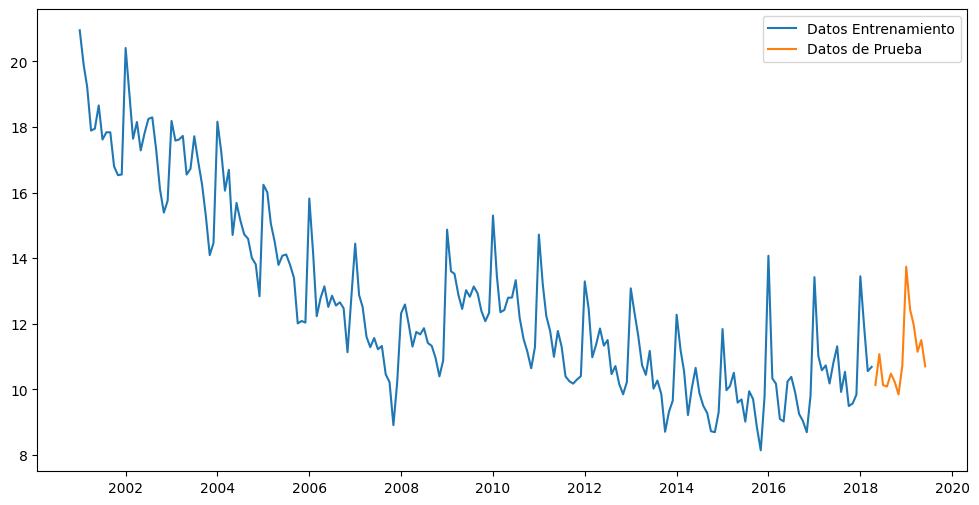

In [7]:
train_len = 208
train_td = data[["TD_13ciudades"]][:train_len]
test_td = data[["TD_13ciudades"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

In [8]:
train_td

,TD_13ciudades
mes,
2001-01-01,20.946380
2001-02-01,19.894213
2001-03-01,19.221565
2001-04-01,17.888575
2001-05-01,17.945654
...,...
2017-12-01,9.837395
2018-01-01,13.446245
2018-02-01,11.874973


In [9]:
test_td

,TD_13ciudades
mes,
2018-05-01,10.129211
2018-06-01,11.071347
2018-07-01,10.125100
2018-08-01,10.085244
2018-09-01,10.476567
2018-10-01,10.230811
2018-11-01,9.844539
2018-12-01,10.725865
2019-01-01,13.739328


## **5. Promedio movil**

El promedio móvil está dado por:

$$ F_{t + 1}=\frac{Y_{t} + Y_{t-1} + Y_{t-(k-1)} }{ k} $$

El método de los promedios móviles utiliza el promedio de los $k$
valores de datos más recientes en la serie de tiempo como el
pronóstico para el siguiente periodo.

El término móvil indica que, mientras se dispone de una nueva
observación para la serie de tiempo, reemplaza a la observación más
antigua de la ecuación anterior y se calcula un promedio nuevo.
Como resultado, el promedio cambiará, o se moverá, conforme surjan
nuevas observaciones.

$Y_{t}$ = Observación en el período t

$F_{t}$ = Pronóstico en el período t

In [10]:
## Considerando el dato actual
ma_2= train_td.rolling(2,min_periods=2).mean()
ma_3= train_td.rolling(3,min_periods=2).mean()
ma_4= train_td.rolling(4,min_periods=2).mean()
ma_5= train_td.rolling(5,min_periods=2).mean()

In [11]:
## Sin considerar el dato actual
ma_2= train_td.shift().rolling(2,min_periods=2).mean()
ma_3= train_td.shift().rolling(3,min_periods=2).mean()
ma_4= train_td.shift().rolling(4,min_periods=2).mean()
ma_5= train_td.shift().rolling(5,min_periods=2).mean()


In [12]:
def fore_ma(datos,w,h):
  data=datos.copy()
  for x in range(1,h+1):
    ind = data.index[-1]
    value = ind + pd.DateOffset(months=1)
    data.loc[value]= data[-w:].mean()
  return data[-h:]

In [13]:
ma_2_f= fore_ma(train_td,2,14)
ma_3_f= fore_ma(train_td,3,14)
ma_4_f= fore_ma(train_td,4,14)
ma_5_f= fore_ma(train_td,5,14)

In [14]:
test_td

,TD_13ciudades
mes,
2018-05-01,10.129211
2018-06-01,11.071347
2018-07-01,10.125100
2018-08-01,10.085244
2018-09-01,10.476567
2018-10-01,10.230811
2018-11-01,9.844539
2018-12-01,10.725865
2019-01-01,13.739328


In [15]:
ma_2_f

,TD_13ciudades
mes,
2018-05-01,10.618803
2018-06-01,10.651004
2018-07-01,10.634904
2018-08-01,10.642954
2018-09-01,10.638929
2018-10-01,10.640941
2018-11-01,10.639935
2018-12-01,10.640438
2019-01-01,10.640187


In [16]:
rmse_ma_2 = np.sqrt(mean_squared_error(test_td,ma_2_f ))
rmse_ma_3 = np.sqrt(mean_squared_error(test_td,ma_3_f ))
rmse_ma_4 = np.sqrt(mean_squared_error(test_td,ma_4_f ))
rmse_ma_5 = np.sqrt(mean_squared_error(test_td,ma_5_f ))

In [17]:
print( rmse_ma_2, rmse_ma_3 ,rmse_ma_4 ,rmse_ma_5)

1.1147962992873541 1.079289141194038 1.0913829514823736 1.079379141938296


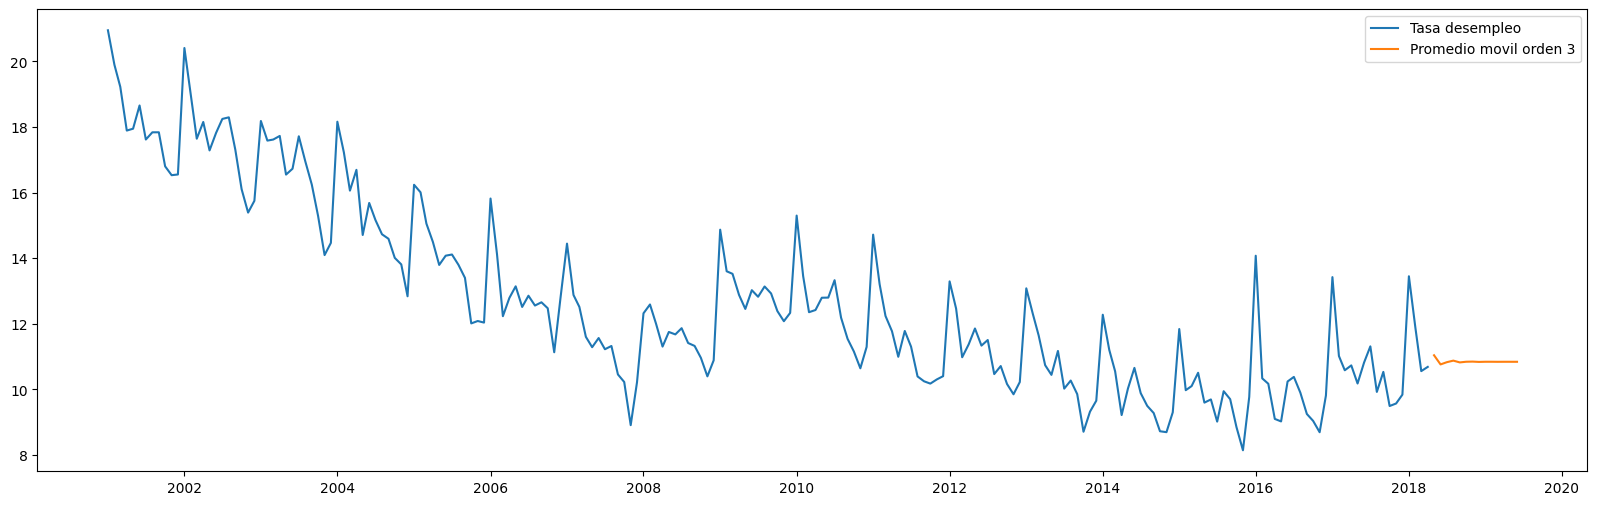

In [18]:
fig = plt.figure(figsize=(20, 6))
plt.plot(train_td,label="Tasa desempleo")
plt.plot(ma_3_f,label="Promedio movil orden 3")
plt.legend()
plt.show()

**INTEGRANTES:**

JUAN CARLOS MOLINA LOZANO

SANTIAGO ALEXIS TOBAR

DIANA MARCELA VELASCO ARCE


## **6. Ejercicio**

Empleando la información del número de ocupados en miles de personas (**Ocupados**) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses. Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyecciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.


# **Pronóstico del número de ocupados**



In [19]:
# Selección de la serie de interés
ocupados = data[["Ocupados"]].copy().sort_index()

print("Número de observaciones:", len(ocupados))
print("Fecha inicial:", ocupados.index.min().strftime("%Y-%m"))
print("Fecha final:", ocupados.index.max().strftime("%Y-%m"))
print("Datos faltantes en Ocupados:", ocupados["Ocupados"].isna().sum())

display(ocupados.head())
display(ocupados.tail())


Número de observaciones: 222
Fecha inicial: 2001-01
Fecha final: 2019-06
Datos faltantes en Ocupados: 0


,Ocupados
mes,
2001-01-01,6923.604
2001-02-01,7037.746
2001-03-01,6945.973
2001-04-01,6973.079
2001-05-01,6994.462


,Ocupados
mes,
2019-02-01,10557.917
2019-03-01,10760.776
2019-04-01,10632.028
2019-05-01,10813.000
2019-06-01,10848.000


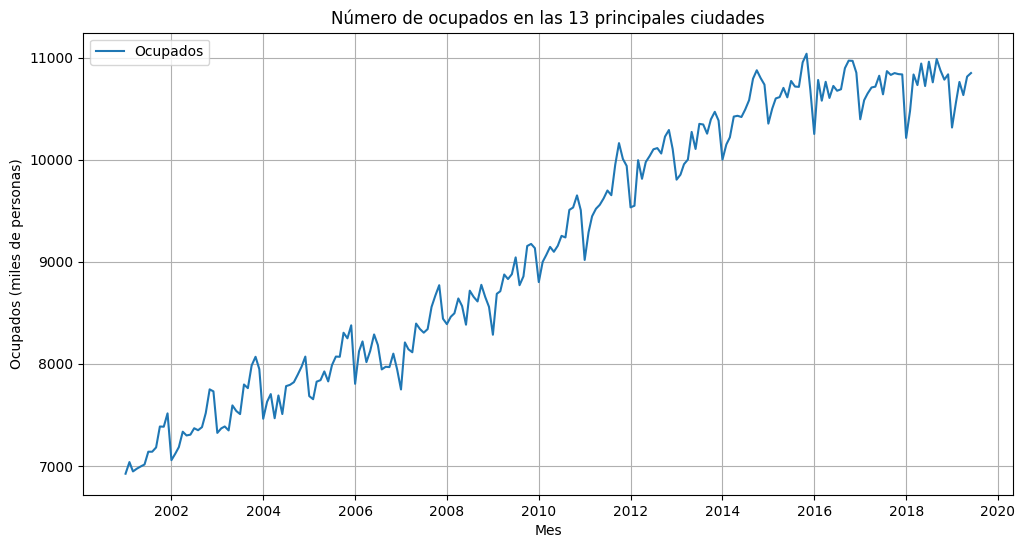

In [20]:
# Gráfica de la serie completa
plt.figure(figsize=(12, 6))
plt.plot(ocupados, label="Ocupados")
plt.title("Número de ocupados en las 13 principales ciudades")
plt.xlabel("Mes")
plt.ylabel("Ocupados (miles de personas)")
plt.legend()
plt.grid()
plt.show()


## **6.1 Exploración de componentes de la serie**

Se realiza una descomposición aditiva como apoyo exploratorio para observar tendencia, posible estacionalidad y componente irregular. Esta gráfica no define el modelo final, pero ayuda a interpretar las limitaciones del promedio móvil.

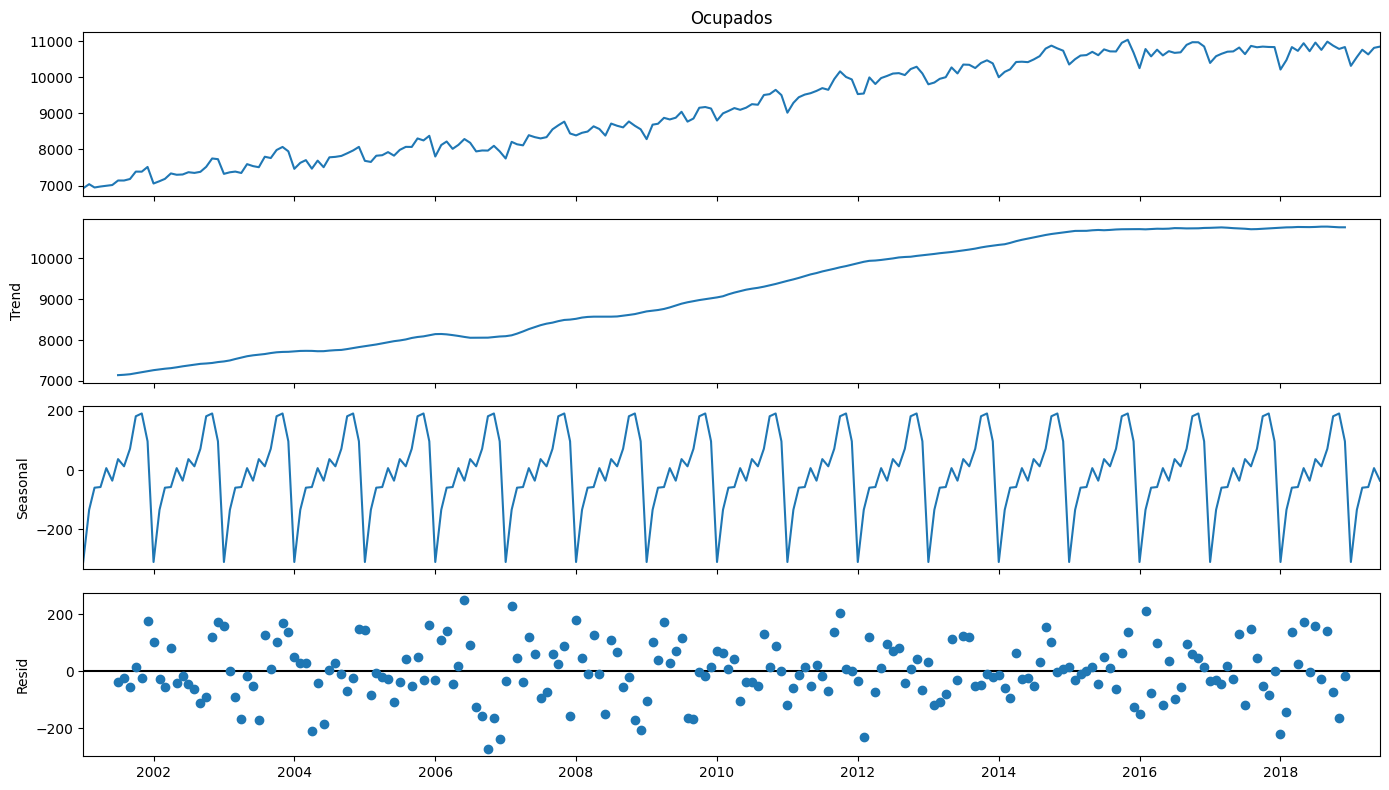

In [21]:
# Descomposición de la serie mensual
componentes_ocupados = seasonal_decompose(ocupados["Ocupados"], model="additive", period=12)

fig = componentes_ocupados.plot()
fig.set_size_inches((14, 8))
fig.tight_layout()
plt.show()


## **6.2 División entre entrenamiento y prueba**

Se reserva la parte final de la serie como conjunto de prueba para evaluar el comportamiento de los modelos fuera de muestra. De esta forma, los pronósticos se comparan contra valores reales que el modelo no usó para entrenarse.

Entrenamiento: 2001-01 a 2018-04
Prueba: 2018-05 a 2019-06
Observaciones de entrenamiento: 208
Observaciones de prueba: 14


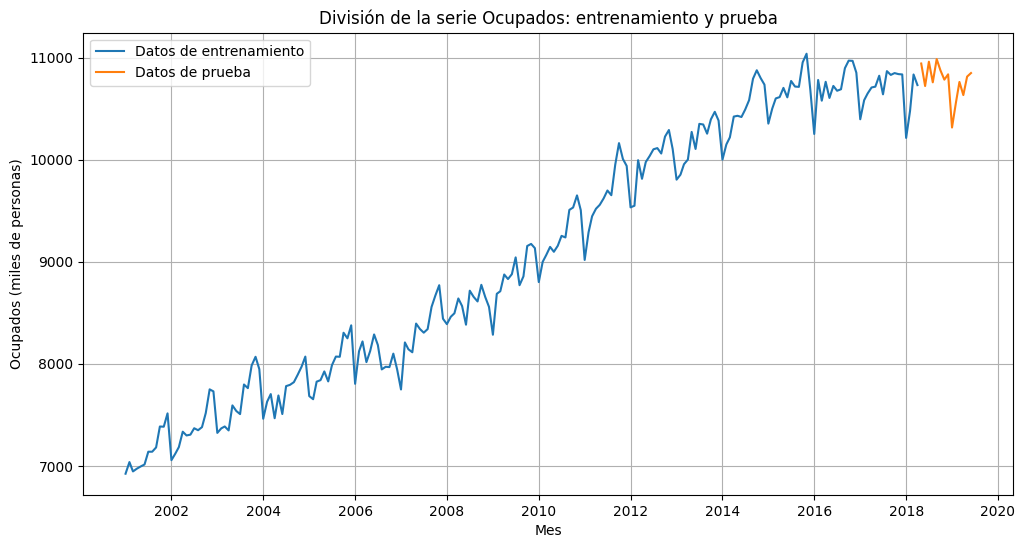

In [22]:
# Protocolo de evaluación
train_len = 208

train_ocupados = ocupados.iloc[:train_len]
test_ocupados = ocupados.iloc[train_len:]

print("Entrenamiento:", train_ocupados.index.min().strftime("%Y-%m"), "a", train_ocupados.index.max().strftime("%Y-%m"))
print("Prueba:", test_ocupados.index.min().strftime("%Y-%m"), "a", test_ocupados.index.max().strftime("%Y-%m"))
print("Observaciones de entrenamiento:", len(train_ocupados))
print("Observaciones de prueba:", len(test_ocupados))

plt.figure(figsize=(12, 6))
plt.plot(train_ocupados, label="Datos de entrenamiento")
plt.plot(test_ocupados, label="Datos de prueba")
plt.title("División de la serie Ocupados: entrenamiento y prueba")
plt.xlabel("Mes")
plt.ylabel("Ocupados (miles de personas)")
plt.legend()
plt.grid()
plt.show()


## **6.3 Modelo de promedio móvil**

El promedio móvil pronostica el siguiente periodo usando el promedio de las últimas `w` observaciones. Para escoger la mejor ventana se evalúan diferentes valores de `w` y se selecciona el que tenga menor RMSE en el conjunto de prueba.

In [23]:
def fore_ma(datos, w, h):
    """Pronóstico iterativo por promedio móvil.

    datos: DataFrame de una columna con índice temporal mensual.
    w: número de observaciones usadas en la ventana.
    h: horizonte de pronóstico.
    """
    serie = datos.copy()

    for _ in range(h):
        siguiente_mes = serie.index[-1] + pd.DateOffset(months=1)
        pronostico = serie.iloc[-w:].mean()
        serie.loc[siguiente_mes, :] = pronostico.values

    return serie.iloc[-h:]


In [24]:
# Evaluación de ventanas de promedio móvil
resultados_rmse = []
pronosticos_prueba = {}

for w in range(2, 11):
    pronostico_w = fore_ma(train_ocupados, w, len(test_ocupados))
    pronosticos_prueba[w] = pronostico_w

    rmse = np.sqrt(mean_squared_error(test_ocupados["Ocupados"], pronostico_w["Ocupados"]))

    resultados_rmse.append({
        "Ventana": w,
        "RMSE (miles de personas)": rmse
    })

tabla_rmse = pd.DataFrame(resultados_rmse).sort_values("RMSE (miles de personas)")
best_w = int(tabla_rmse.iloc[0]["Ventana"])
best_rmse = float(tabla_rmse.iloc[0]["RMSE (miles de personas)"])

print(f"La mejor ventana es w={best_w}, con RMSE={best_rmse:.2f} miles de personas.")
display(tabla_rmse.style.format({"RMSE (miles de personas)": "{:,.2f}"}))


La mejor ventana es w=2, con RMSE=169.19 miles de personas.


,Ventana,RMSE (miles de personas)
0,2,169.19
1,3,181.44
8,10,195.10
7,9,196.83
6,8,202.21
5,7,204.31
2,4,212.78
4,6,213.33
3,5,217.05


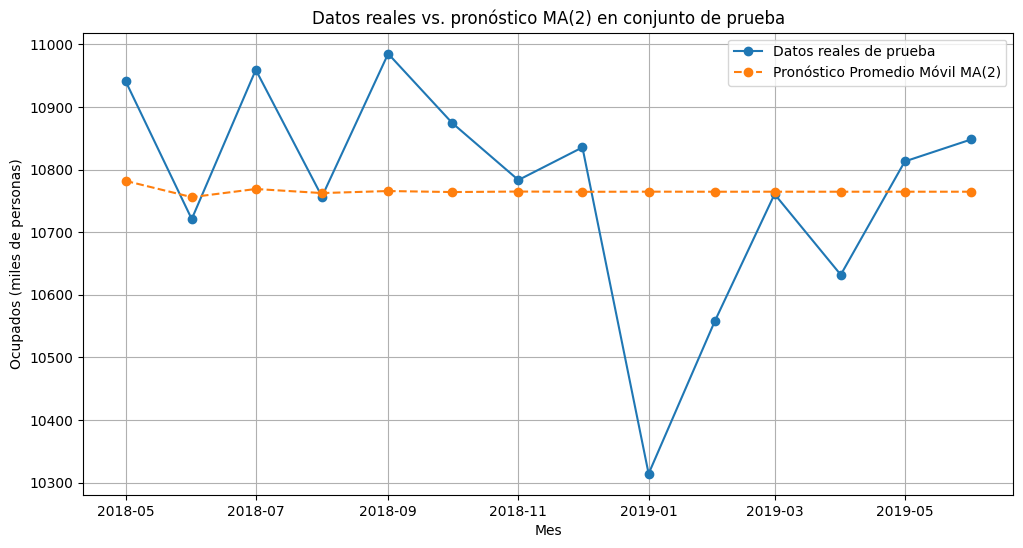

In [25]:
# Comparación gráfica: valores reales de prueba vs. mejor pronóstico
mejor_pronostico_prueba = pronosticos_prueba[best_w]

plt.figure(figsize=(12, 6))
plt.plot(test_ocupados, label="Datos reales de prueba", marker="o")
plt.plot(mejor_pronostico_prueba, label=f"Pronóstico Promedio Móvil MA({best_w})", linestyle="--", marker="o")
plt.title(f"Datos reales vs. pronóstico MA({best_w}) en conjunto de prueba")
plt.xlabel("Mes")
plt.ylabel("Ocupados (miles de personas)")
plt.legend()
plt.grid()
plt.show()


## **6.4 Pronóstico final a 6 meses**

Después de seleccionar la mejor ventana con el conjunto de prueba, se utiliza toda la serie disponible para pronosticar los siguientes seis meses.

In [26]:
# Pronóstico final usando toda la serie
pronostico_final = fore_ma(ocupados, best_w, 6)

tabla_pronostico_final = pronostico_final.rename(
    columns={"Ocupados": "Pronóstico ocupados (miles de personas)"}
)
tabla_pronostico_final.index.name = "Mes"

display(tabla_pronostico_final.style.format({"Pronóstico ocupados (miles de personas)": "{:,.2f}"}))


,Pronóstico ocupados (miles de personas)
Mes,
2019-07-01 00:00:00,"10,830.50"
2019-08-01 00:00:00,"10,839.25"
2019-09-01 00:00:00,"10,834.88"
2019-10-01 00:00:00,"10,837.06"
2019-11-01 00:00:00,"10,835.97"
2019-12-01 00:00:00,"10,836.52"


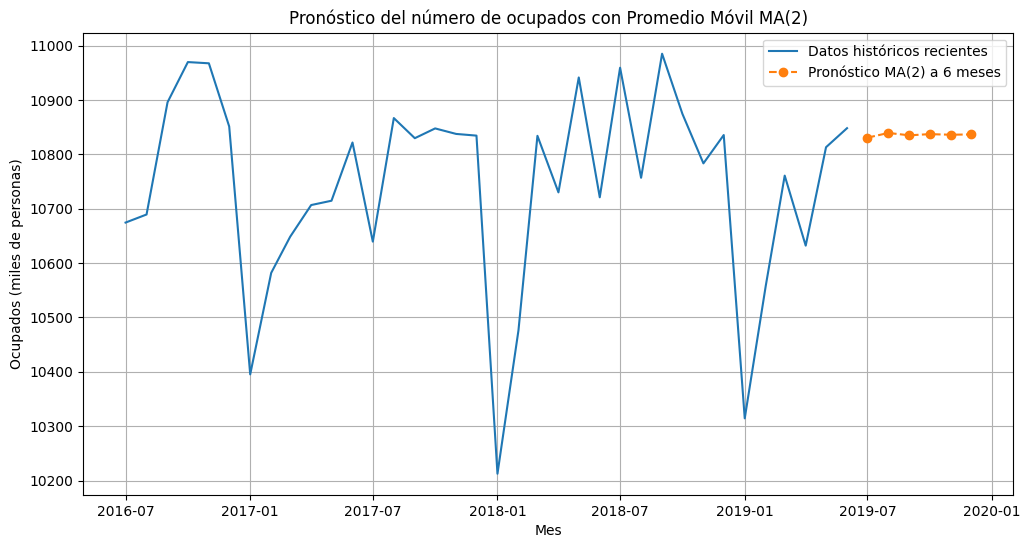

In [27]:
# Gráfica del pronóstico final
plt.figure(figsize=(12, 6))
plt.plot(ocupados.tail(36), label="Datos históricos recientes")
plt.plot(pronostico_final, label=f"Pronóstico MA({best_w}) a 6 meses", linestyle="--", marker="o")
plt.title(f"Pronóstico del número de ocupados con Promedio Móvil MA({best_w})")
plt.xlabel("Mes")
plt.ylabel("Ocupados (miles de personas)")
plt.legend()
plt.grid()
plt.show()


## **6.5 Informe final**

**Pronóstico del número de ocupados en las 13 principales ciudades**

Se analizó la serie mensual del número de ocupados en las 13 principales ciudades de Colombia, medida en miles de personas. La base contiene 222 observaciones mensuales, desde enero de 2001 hasta junio de 2019. El objetivo fue seleccionar el mejor modelo de promedio móvil para proyectar los siguientes seis meses de la serie, correspondientes al periodo julio-diciembre de 2019.

Inicialmente se realizó una exploración gráfica de la serie y una descomposición aditiva para observar su comportamiento general. Posteriormente, la información se dividió en dos conjuntos: datos de entrenamiento y datos de prueba. El conjunto de entrenamiento incluyó las primeras 208 observaciones, desde enero de 2001 hasta abril de 2018, mientras que el conjunto de prueba incluyó las últimas 14 observaciones, desde mayo de 2018 hasta junio de 2019. Esta división permitió evaluar el desempeño de los modelos fuera de muestra, comparando los valores observados con los valores pronosticados.

Para seleccionar el mejor modelo se evaluaron promedios móviles con ventanas entre 2 y 10 meses. El criterio de selección fue la raíz del error cuadrático medio, RMSE. Los resultados mostraron que la ventana de 2 meses presentó el menor error, con un RMSE de 169.19 miles de personas. Por esta razón, el modelo seleccionado fue el promedio móvil de orden 2, MA(2). Este resultado indica que, dentro de las alternativas evaluadas, el mejor pronóstico se obtiene usando el promedio de los dos meses más recientes.

Con el modelo MA(2), las proyecciones para los próximos seis meses fueron: julio de 2019: 10,830.50; agosto de 2019: 10,839.25; septiembre de 2019: 10,834.88; octubre de 2019: 10,837.06; noviembre de 2019: 10,835.97; y diciembre de 2019: 10,836.52 miles de personas. En general, el modelo proyecta un comportamiento relativamente estable del número de ocupados, alrededor de 10.8 millones de personas.

Sin embargo, estos pronósticos tienen limitaciones. El promedio móvil es un método simple que suaviza la serie y no modela explícitamente la tendencia, la estacionalidad ni posibles cambios estructurales del mercado laboral. Además, al generar varios meses hacia adelante, el modelo usa pronósticos previos como insumo, lo cual puede propagar errores. Por tanto, los resultados deben interpretarse como una aproximación de corto plazo, válida bajo el supuesto de que el comportamiento futuro será similar al observado recientemente.

Anexo: informe final con graficas y tablas en formato PDF (1 pagina).